In [ ]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
)
prep.prepare()



In [ ]:
import shutil
from FIT_python.pipeline_sex.pipeline_wrapper_sex import _cache_dir

# Cache-Verzeichnis komplett entfernen
shutil.rmtree(_cache_dir)
print(f"Cache gelöscht: {_cache_dir}")


In [ ]:
# %% [code] RandomizedGridSearchCV mit Standard-Metriken & Custom-Auswertung (aggregiert)
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
import joblib
from functools import reduce
import operator

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from FIT_python.pipeline_sex.transform_wrapper                import NumericTransformer
from FIT_python.pipeline_sex.feature_selection_wrapper        import FeatureSelectionTransformer
from FIT_python.pipeline_sex.outlier_wrapper                  import OutlierCleanerTransformer
from FIT_python.pipeline_sex.feature_scaler_wrapper           import FeatureScalerTransformer
from FIT_python.pipeline_sex.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.pipeline_sex.models                           import MODELS
from FIT_python.pipeline_sex.grouped_metrics                  import individual_accuracies, individual_majority_stats
from FIT_python.config                                        import SPLITS_DIR, RESULTS_DATA_DIR

import warnings
from sklearn.exceptions import ConvergenceWarning

# Warnings nur einmal
warnings.filterwarnings("once", category=ConvergenceWarning, message="Objective did not converge.*")
warnings.filterwarnings("once", category=UserWarning,       message="X does not have valid feature names.*")

# 1) Modell‐Keys
model_keys = [
    "logreg_l2","logreg_l1",
    "rf_small","rf_med","rf_large",
    "knn_3","knn_5","knn_7",
    "svm_linear","svm_rbf",
    "xgb_std","xgb_hist",
    "lgbm_std","lgbm_md10",
    "lda",
]

# 2) Param‐Räume (inkl. PCA/UMAP‐ & Outlier‐Hyperparams)
param_distributions = {
    # Feature Selection (inkl. RF)
    "select__method":          [None, "forward", "lasso", "variance", "random_forest"],
    "select__k":               [1,2,3,4,5,6,10, 20, 50,100],

    # --- nachher ---
    "outlier__method":         [None, "clip"],
    "outlier__lower_quantile": [0.01, 0.05],
    "outlier__upper_quantile": [0.90, 0.95],

    # Scaling
    "scale__method":           [None, "standard", "robust", "minmax"],

    # DimRed Pre
    "reduce_pre__method":        [None, "pca", "umap"],
    "reduce_pre__n_components":  [2, 10],
    "reduce_pre__n_neighbors":   [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_pre__min_dist":      [0.1, 0.5],
    "reduce_pre__whiten":        [False, True],

    # DimRed Post
    "reduce_post__method":       [None, "pca", "umap"],
    "reduce_post__n_components": [2, 10],
    "reduce_post__n_neighbors":  [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_post__min_dist":     [0.1, 0.5],
    "reduce_post__whiten":       [False, True],

    # Classifier
    "clf": [MODELS[k] for k in model_keys],
}

# 3) Wie groß ist der Suchraum?
lengths = {k: len(v) for k,v in param_distributions.items()}
total_combinations = reduce(operator.mul, lengths.values(), 1)

print("Anzahl der Werte pro Parameter:")
for k, l in lengths.items():
    print(f"  {k:25s}: {l}")
print(f"\n→ Gesamtzahl aller Hyper‐Kombinationen: {total_combinations:,}")


# 3) Ergebnis-Ordner
base_dir = Path(RESULTS_DATA_DIR) / "random_search_standard_metrics"
base_dir.mkdir(parents=True, exist_ok=True)

# Unterordner für Best-Modelle je Metrik
metrics = [
    "maj_test_pct",
    "balanced_test_acc",      # <-- hier
    "accuracy_test",
    "mean_test_neg_log_loss"
]
for m in metrics:
    (base_dir / f"best_{m}").mkdir(exist_ok=True)

# 4) Scoring-Dict
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "neg_log_loss":      "neg_log_loss",
}

pipeline_order = [
    "outlier__method", "outlier__lower_quantile", "outlier__upper_quantile",
    "scale__method", "select__method", "select__k",
    "reduce_pre__method", "reduce_pre__n_components", "reduce_pre__n_neighbors", "reduce_pre__min_dist", "reduce_pre__whiten",
    "reduce_post__method", "reduce_post__n_components", "reduce_post__n_neighbors", "reduce_post__min_dist", "reduce_post__whiten",
    "clf"
]


# 5) Sammel-Listen
raw_records  = []
best_records = []

# 6) Loop über Spezies
for species_dir in tqdm(sorted(Path(SPLITS_DIR).iterdir()), desc="Species"):
    if not species_dir.is_dir(): 
        continue
    species = species_dir.name
    print(f"\n🔄 Processing species: {species}")

    # 6.1) Train/Test laden & Fold entfernen
    df_train = (pd.read_parquet(species_dir / "train.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))
    df_test  = (pd.read_parquet(species_dir / "test.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))

    # 🔍 Feature-Spalten abhängig von Spezies auswählen
    if species == "eurasian_otter":
        feature_cols = [
            c for c in df_train.columns 
            if c.startswith(("dist", "ang", "t")) and pd.api.types.is_numeric_dtype(df_train[c])
        ]
    else:
        feature_cols = [
            c for c in df_train.columns[5:] 
            if pd.api.types.is_numeric_dtype(df_train[c])
        ]
    print(f"  → {len(feature_cols)} numerische Features")

    # 6.2) Features, Ziel & IDs
    X_tr, y_tr, ids_tr = (
        df_train[feature_cols],
        df_train["sex"].map({"f":0,"m":1}).values,
        df_train["individual_id"].values
    )
    X_te, y_te, ids_te = (
        df_test[feature_cols],
        df_test["sex"].map({"f":0,"m":1}).values,
        df_test["individual_id"].values
    )

    # 6.3) Pipeline
    steps = [
        ("transform",   NumericTransformer()),                                   # 1) Grund-Transformationen
        ("outlier",     OutlierCleanerTransformer(method="clip")),               # 2) Ausreißer entfernen
        ("scale",       FeatureScalerTransformer(method="standard")),            # 3) Skalierung
        ("select",      FeatureSelectionTransformer(method="forward", k=1)),     # 4) Feature-Selektion
        ("reduce_pre",  DimensionalityReducerTransformer(method=None, n_components=1)),  # 5) erste Dimensionstahlung
        ("reduce_post", DimensionalityReducerTransformer(method=None, n_components=1)),  # 6) zweite Dimensionstahlung (z. B. Visualisierung)
        ("clf",         MODELS["rf_small"]),                                     # 7) Klassifikator
    ]
    pipe = Pipeline(steps)

    # 6.4) RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=1000,      # kleiner Testdurchgang
        scoring=scoring,
        refit=False,
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )

# 6.5) Fit mit tqdm (dynamisch berechnete Gesamt-Anzahl an Fits)
    n_iter = search.n_iter
    # wenn cv ein Integer ist, nutzen wir es direkt, sonst versuchen wir n_splits zu lesen
    folds  = search.cv if isinstance(search.cv, int) else getattr(search.cv, "n_splits", len(list(search.cv)))
    total_fits = n_iter * folds

    with tqdm_joblib(tqdm(desc=f"{species} RS-CV", total=total_fits, leave=False)):
        search.fit(X_tr, y_tr)

    # 6.6) CV-Ergebnisse & Custom-Metriken sammeln
    cv_res = search.cv_results_
    for i, params in enumerate(cv_res["params"]):
        record = {
            "species":                     species,
            "mean_test_accuracy":          cv_res["mean_test_accuracy"][i],
            "mean_test_balanced_accuracy": cv_res["mean_test_balanced_accuracy"][i],
            "mean_test_neg_log_loss":      cv_res["mean_test_neg_log_loss"][i],
            **params
        }
        # kompletter Re-Fit für Custom-Metriken
        mdl = clone(pipe).set_params(**params).fit(X_tr, y_tr)
        y_tr_pred = mdl.predict(X_tr)
        y_te_pred = mdl.predict(X_te)
        y_all_true = np.concatenate([y_tr, y_te])
        y_all_pred = np.concatenate([y_tr_pred, y_te_pred])
        ids_all     = np.concatenate([ids_tr, ids_te])

        fem_tr, mal_tr, bal_tr    = individual_accuracies(y_tr, y_tr_pred, ids_tr)
        fem_te, mal_te, bal_te    = individual_accuracies(y_te, y_te_pred, ids_te)
        ct_tr, wr_tr, pct_tr      = individual_majority_stats(y_tr, y_tr_pred, ids_tr)
        ct_te, wr_te, pct_te      = individual_majority_stats(y_te, y_te_pred, ids_te)
        fem_all, mal_all, bal_all = individual_accuracies(y_all_true, y_all_pred, ids_all)
        ct_all, wr_all, pct_all   = individual_majority_stats(y_all_true, y_all_pred, ids_all)
                # Accuracy & Balanced Accuracy
        acc_tr  = accuracy_score(y_tr,  y_tr_pred)
        bal_tr  = balanced_accuracy_score(y_tr,  y_tr_pred)
        acc_te  = accuracy_score(y_te,  y_te_pred)
        bal_te  = balanced_accuracy_score(y_te,  y_te_pred)

        # Neu: Full-Dataset Accuracy & Balanced Accuracy
        acc_all = accuracy_score(y_all_true, y_all_pred)
        bal_all = balanced_accuracy_score(y_all_true, y_all_pred)

        

        record.update({
            "female_train_acc":   fem_tr, "male_train_acc":   mal_tr, "balanced_train_acc": bal_tr, "accuracy_train":          acc_tr,
            "female_test_acc":    fem_te, "male_test_acc":    mal_te, "balanced_test_acc":  bal_te, "accuracy_test":          acc_te,
            "female_full_acc":    fem_all,"male_full_acc":    mal_all,"balanced_full_acc":  bal_all,"accuracy_full":          acc_all,
            "maj_train_count":    ct_tr, "maj_train_wrong":  wr_tr, "maj_train_pct":      pct_tr,
            "maj_test_count":     ct_te, "maj_test_wrong":   wr_te, "maj_test_pct":       pct_te,
            "maj_full_count":     ct_all,"maj_full_wrong":   wr_all,"maj_full_pct":       pct_all,
        })
        
        # 1) pipeline_id bauen
        pid_parts = []
        for key in pipeline_order:
            val = params.get(key)
            pid_parts.append(f"{key}={val if val is not None else 'None'}")
        record["pipeline_id"] = ";".join(pid_parts)

        # 2) Alle NaNs in "None" umwandeln
        for k, v in record.items():
            if pd.isna(v):
                record[k] = "None"
        raw_records.append(record)

# 6.7) Beste Modelle je Metrik speichern UND Joblib dump
    df_eval = pd.DataFrame([r for r in raw_records if r["species"] == species])
    for metric in metrics:
        # Index und Parameter des besten Runs finden
        best_idx    = df_eval[metric].idxmax()
        best_params = cv_res["params"][best_idx]
        # Erstelle das Record-Dict für best_records
        best_record = df_eval.loc[best_idx].to_dict()
        best_record["best_metric"] = metric

        # Finales Modell trainieren und speichern
        best_pipe = clone(pipe).set_params(**best_params).fit(X_tr, y_tr)
        out_path = base_dir / f"best_{metric}" / f"{species}.joblib"
        joblib.dump(best_pipe, out_path)
        print(f"✅ Modell für Spezies '{species}', Kriterium '{metric}' gespeichert unter:\n   {out_path}")

        # **Ganz wichtig**: best_record in best_records einfuegen
        best_records.append(best_record)

    # → CSVs direkt aktualisieren (innerhalb des Species-Loops)
    all_csv  = base_dir / "all_results.csv"
    best_csv = base_dir / "best_models.csv"
    # DataFrames bauen und alle NaNs in "None" umwandeln
    df_all  = pd.DataFrame(raw_records).fillna("None")
    df_best = pd.DataFrame(best_records).fillna("None")

    # CSVs speichern
    df_all.to_csv(all_csv,  index=False)
    df_best.to_csv(best_csv, index=False)



In [ ]:
print(df_eval.columns.tolist())


In [2]:
import pandas as pd
from joblib import load

# Pfade definieren
model_path = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/random_search_standard_metrics/best_maj_test_pct/eurasian_otter.joblib"
data_path  = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/data/raw/Eurasian Otter.csv"
output_csv = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv"

# Modell laden
clf = load(model_path)

# Daten laden und Spaltennamen anpassen (Punkte, Bindestriche → Unterstriche; T → t)
df = pd.read_csv(data_path)
df.columns = [
    col.replace('.', '_')
       .replace('-', '_')
       .replace('T', 't')
    for col in df.columns
]

# Direkt Vorhersagen aus der Pipeline holen
df["predicted_sex"]     = clf.predict(df)
probas = clf.predict_proba(df)
df["predicted_proba_f"] = probas[:, 0]
df["predicted_proba_m"] = probas[:, 1]

# Ergebnisse als CSV speichern
df.to_csv(output_csv, index=False)
print(f"Ergebnisse gespeichert in: {output_csv}")


Ergebnisse gespeichert in: C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv


Spalten im DataFrame: ['Species', 'animal', 'Date', 'Location', 'Dataorigin', 'Substrate', 'Sex', 'trail', 'dist1_2', 'dist1_3', 'dist1_4', 'dist1_5', 'dist1_6', 'dist1_7', 'dist1_8', 'dist1_9', 'dist1_10', 'dist1_11', 'dist1_12', 'dist1_13', 'dist1_14', 'dist1_15', 'dist1_16', 'dist1_17', 'dist2_3', 'dist2_4', 'dist2_5', 'dist2_6', 'dist2_7', 'dist2_8', 'dist2_9', 'dist2_10', 'dist2_11', 'dist2_12', 'dist2_13', 'dist2_14', 'dist2_15', 'dist2_16', 'dist2_17', 'dist3_4', 'dist3_5', 'dist3_6', 'dist3_7', 'dist3_8', 'dist3_9', 'dist3_10', 'dist3_11', 'dist3_12', 'dist3_13', 'dist3_14', 'dist3_15', 'dist3_16', 'dist3_17', 'dist4_5', 'dist4_6', 'dist4_7', 'dist4_8', 'dist4_9', 'dist4_10', 'dist4_11', 'dist4_12', 'dist4_13', 'dist4_14', 'dist4_15', 'dist4_16', 'dist4_17', 'dist5_6', 'dist5_7', 'dist5_8', 'dist5_9', 'dist5_10', 'dist5_11', 'dist5_12', 'dist5_13', 'dist5_14', 'dist5_15', 'dist5_16', 'dist5_17', 'dist6_7', 'dist6_8', 'dist6_9', 'dist6_10', 'dist6_11', 'dist6_12', 'dist6_13', 'd

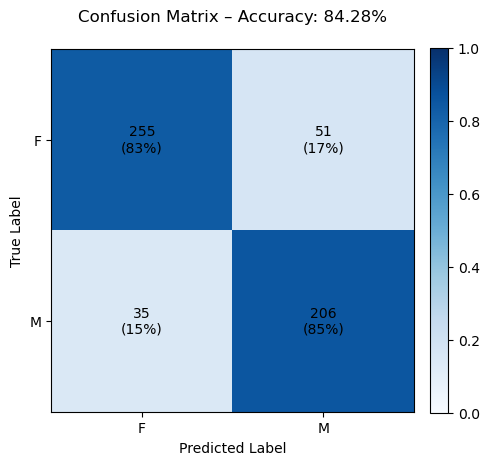

Overall Accuracy (All Predictions):           84.28% (n = 547)
Accuracy (High Confidence only):               94.14% (n = 273)
Accuracy (High + Moderate Confidence):         89.43% (n = 435)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# === 1) CSV laden ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv"
df = pd.read_csv(file_path)

# === 2) Spaltennamen ausgeben zum Debug (optional) ===
print("Spalten im DataFrame:", df.columns.tolist())

# === 3) Filter & Mapping ===
# Nur Zeilen mit vorhandener Vorhersage behalten
df = df[df["predicted_sex"].notna()]

# Numeric-Prediction → Buchstaben-Labels (groß)
label_map = {0: "F", 1: "M"}
df["pred_label"] = df["predicted_sex"].astype(int).map(label_map)

# True-Labels aus der Originalspalte, ebenfalls groß
df["true_label"] = df["Sex"].str.upper()

# === 4) Confusion-Matrix-Funktion ===
def get_conf_matrix(y_true, y_pred, labels=["F", "M"]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / row_sums
        cm_norm[np.isnan(cm_norm)] = 0

    annot = np.empty_like(cm).astype(object)
    for i in range(len(labels)):
        for j in range(len(labels)):
            cnt = cm[i, j]
            pct = int(round(cm_norm[i, j] * 100))
            annot[i, j] = f"{cnt}\n({pct}%)"

    acc = accuracy_score(y_true, y_pred)
    return cm_norm, annot, acc

# === 5) Confusion-Matrix & Accuracy berechnen ===
mask = df["true_label"].isin(["F","M"]) & df["pred_label"].isin(["F","M"])
df_cm = df[mask]
cm, annot, acc = get_conf_matrix(df_cm["true_label"], df_cm["pred_label"])

# === 6) Plot ===
plt.figure(figsize=(5,5))
plt.title(f"Confusion Matrix – Accuracy: {acc:.2%}", pad=20)
im = plt.imshow(cm, vmin=0, vmax=1, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
labels = ["F", "M"]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, annot[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

# === 7) Prediction Quality einteilen ===
# Maximalwahrscheinlichkeit pro Zeile
df["Max_Prob"] = df[["predicted_proba_f", "predicted_proba_m"]].max(axis=1)

# Quality-Kategorien
def classify_quality(p):
    if p > 0.9:
        return "High Confidence"
    elif p > 0.7:
        return "Moderate Confidence"
    else:
        return "Low Confidence"

df["Prediction Quality"] = df["Max_Prob"].apply(classify_quality)

# Richtig/Falsch markieren
df["Correct"] = df["pred_label"] == df["true_label"]

# === 8) Confidence-Accuracies ausgeben ===
# Nur gültige F/M-Zeilen
df_cm = df[df["true_label"].isin(["F", "M"])]

total     = df_cm
high      = df_cm[df_cm["Prediction Quality"] == "High Confidence"]
high_mod  = df_cm[df_cm["Prediction Quality"].isin(["High Confidence", "Moderate Confidence"])]

acc_total    = total["Correct"].mean()    if len(total)   > 0 else np.nan
acc_high     = high["Correct"].mean()     if len(high)    > 0 else np.nan
acc_high_mod = high_mod["Correct"].mean() if len(high_mod)> 0 else np.nan

print(f"Overall Accuracy (All Predictions):           {acc_total:.2%} (n = {len(total)})")
print(f"Accuracy (High Confidence only):               {acc_high:.2%} (n = {len(high)})")
print(f"Accuracy (High + Moderate Confidence):         {acc_high_mod:.2%} (n = {len(high_mod)})")


C:\Users\Frede\AppData\Local\Temp\ipykernel_540\2051291789.py:56: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_block.applymap(lambda x: f"{int(x)}\n({int(round(x/total*100))}%)" if total>0 else "0\n(0%)")


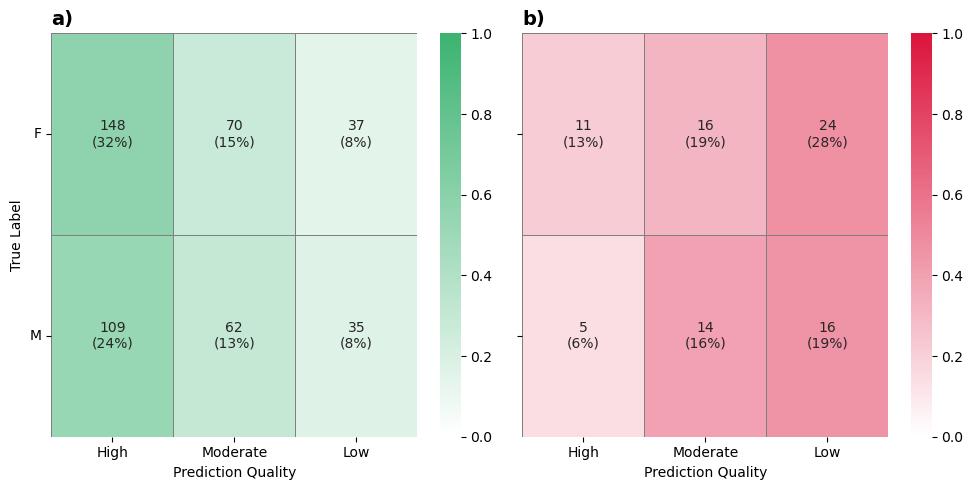

Plot gespeichert.


<Figure size 640x480 with 0 Axes>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === 1) CSV laden ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv"
df = pd.read_csv(file_path)

save_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/figures/plots otter/prediction_qality_single_print.png"

# === 2) Filter & Mapping ===
df = df[df["predicted_sex"].notna()]  # NaNs raus
label_map = {0: "F", 1: "M"}
df["pred_label"] = df["predicted_sex"].astype(int).map(label_map)
df["true_label"] = df["Sex"].str.upper()  # 'f' → 'F'

# === 3) Korrektheit prüfen ===
df["Correct"] = df["pred_label"] == df["true_label"]

# === 4) Prediction Quality ===
df["Max_Prob"] = df[["predicted_proba_f", "predicted_proba_m"]].max(axis=1)

def classify_quality(p):
    if p > 0.9:
        return "High"
    elif p > 0.7:
        return "Moderate"
    else:
        return "Low"

df["Quality"] = df["Max_Prob"].apply(classify_quality)

# === 5) Gruppieren und Pivotieren ===
counts = (
    df
    .groupby(["true_label", "Correct", "Quality"])
    .size()
    .reset_index(name="Count")
    .pivot_table(
        index=["true_label", "Correct"],
        columns="Quality",
        values="Count",
        fill_value=0
    )
    .loc[:, ["High","Moderate","Low"]]  # feste Spaltenreihenfolge
)

# Zeilen-normalisieren
normed = counts.div(counts.sum(axis=1), axis=0).fillna(0)

# Annotationstext: absolute Zahl + Prozent
def make_annot(df_block):
    total = df_block.values.sum()
    return df_block.applymap(lambda x: f"{int(x)}\n({int(round(x/total*100))}%)" if total>0 else "0\n(0%)")

corr = normed.loc[normed.index.get_level_values("Correct")]
incorr = normed.loc[~normed.index.get_level_values("Correct")]
counts_corr = counts.loc[counts.index.get_level_values("Correct")]
counts_incorr = counts.loc[~counts.index.get_level_values("Correct")]
annot_corr = make_annot(counts_corr)
annot_incorr = make_annot(counts_incorr)

# === 6) Plot ===
green_cmap = LinearSegmentedColormap.from_list("green", ["white","mediumseagreen"])
red_cmap   = LinearSegmentedColormap.from_list("red",   ["white","crimson"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# korrekt
sns.heatmap(
    corr,
    annot=annot_corr,
    fmt="",
    cmap=green_cmap,
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="gray",
    ax=axes[0],
    cbar=True
)
axes[0].set_title("a)",loc='left', fontsize=14, fontweight="bold") #"Correct Predictions"
axes[0].set_ylabel("True Label")

# falsch
sns.heatmap(
    incorr,
    annot=annot_incorr,
    fmt="",
    cmap=red_cmap,
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="gray",
    ax=axes[1],
    cbar=True
)
axes[1].set_title("b)",loc='left', fontsize=14, fontweight="bold")#Incorrect Predictions
axes[1].set_ylabel("")

for ax in axes:
    ax.set_xlabel("Prediction Quality")
    ax.set_xticklabels(["High", "Moderate", "Low"], rotation=0)
    ax.set_yticklabels(["F", "M"], rotation=0)

plt.tight_layout()
plt.show()
# Speichern vor show
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Plot gespeichert.")
plt.show()


Lese CSV von: C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv
Shape df: (628, 216)
       Species   animal Date    Location       Dataorigin Substrate Sex  \
0  Lutra lutra  Zanetka  NaN  ZOO Ohrada  Vetrecova et al       Mud   F   
1  Lutra lutra  Zanetka  NaN  ZOO Ohrada  Vetrecova et al       Mud   F   
2  Lutra lutra  Zanetka  NaN  ZOO Ohrada  Vetrecova et al       Mud   F   
3  Lutra lutra  Zanetka  NaN  ZOO Ohrada  Vetrecova et al       Mud   F   
4  Lutra lutra  Zanetka  NaN  ZOO Ohrada  Vetrecova et al       Mud   F   

     trail          dist1_2          dist1_3  ...         t5_6_10  \
0  Zanetka  1,5515453038231  2,6828165560631  ...  7,925469368808   
1  Zanetka  1,3102619415505  2,5729221105029  ...  7,288812885238   
2  Zanetka  1,7855561405774  2,9120417488058  ...  7,674239572465   
3  Zanetka   1,606557549303   2,778973327193  ...  7,778056874422   
4  Zanetka  1,7518140480703   3,004309640943  ...  9,2532653397

C:\Users\Frede\AppData\Local\Temp\ipykernel_540\3920452615.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trail_quality  = df.groupby(["trail",  "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")
C:\Users\Frede\AppData\Local\Temp\ipykernel_540\3920452615.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  animal_quality = df.groupby(["animal", "true_label"]).apply(classify_majority_accu

Plot gespeichert.


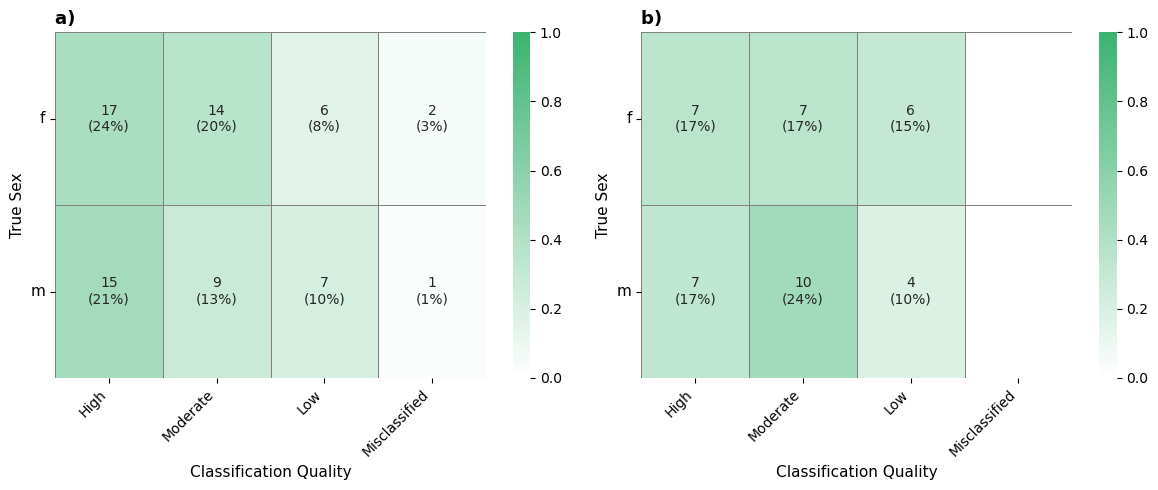

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# === CSV einlesen ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/eurasian_otter_predictions.csv"
print("Lese CSV von:", file_path)
df = pd.read_csv(file_path)
print("Shape df:", df.shape)
print(df.head())

# === Vorverarbeitung: Labels vereinheitlichen ===
df["true_label"] = df["Sex"].astype(str).str.lower().str.strip()
df["predicted_sex"] = df["predicted_sex"].map({0: "f", 1: "m"})
df = df[df["true_label"].isin(["f", "m"])].copy()
df["Correct"] = df["predicted_sex"] == df["true_label"]
print("Nach Filterung auf f/m, Shape df:", df.shape)

# === Klassifikationsqualität berechnen ===
def classify_majority_accuracy(group):
    acc = group["Correct"].mean()
    if acc >= 0.9:        return "High"
    elif acc >= 0.7:      return "Moderate"
    elif acc >= 0.5:      return "Low"
    else:                 return "Misclassified"

trail_quality  = df.groupby(["trail",  "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")
animal_quality = df.groupby(["animal", "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")
print("Trail_quality sample:\n", trail_quality.head())
print("Animal_quality sample:\n", animal_quality.head())

# === Gruppieren & Pivots ===
conf_trail  = trail_quality.groupby(["true_label","Class"]).size().reset_index(name="Count")
conf_animal = animal_quality.groupby(["true_label","Class"]).size().reset_index(name="Count")

pivot_trail  = (conf_trail .pivot_table(index="true_label", columns="Class", values="Count", fill_value=0)
                    .reindex(columns=["High","Moderate","Low","Misclassified"], fill_value=0))
pivot_animal = (conf_animal.pivot_table(index="true_label", columns="Class", values="Count", fill_value=0)
                    .reindex(columns=["High","Moderate","Low","Misclassified"], fill_value=0))

# Fehlende Kombinationen ergänzen
for p in [pivot_trail, pivot_animal]:
    for sex in ["f","m"]:
        if sex not in p.index:
            p.loc[sex] = 0
    for col in ["High","Moderate","Low","Misclassified"]:
        if col not in p.columns:
            p[col] = 0
    # Sortiere Zeilen alphabetisch
    p.sort_index(inplace=True)

print("Pivot Trail:\n", pivot_trail)
print("Pivot Animal:\n", pivot_animal)

# === Visualisierung ===
save_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/figures/plots otter/heatmaps_majority_classification_trail_and_individual_level_ALL_fixed.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
print("Speichere Plot nach:", save_path)

cmap = LinearSegmentedColormap.from_list("trail_green", ["white","mediumseagreen"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_labels    = ["High","Moderate","Low","Misclassified"]
x_tick_positions = np.arange(len(class_labels)) + 0.5
y_labels        = ["f","m"]
y_tick_positions = np.arange(len(y_labels)) + 0.5

for (pivot, title, ax) in zip(
        [pivot_trail, pivot_animal],
        ["a) ", "b) "], #a trail level b animal level
        axes
    ):
    totals      = pivot.sum(axis=1)
    proportions = pivot.div(totals, axis=0).fillna(0)
    counts      = pivot.astype(int)
    total_sum   = counts.values.sum()
    print(f"{title} totals per class:\n", counts)
    print(f"{title} total_sum = {total_sum}")

    annot = counts.applymap(lambda v: f"{v}\n({v/total_sum:.0%})" if v>0 else "")

    sns.heatmap(
        proportions,
        annot=annot, fmt="",
        cmap=cmap, vmin=0, vmax=1,
        linewidths=0.5, linecolor="gray",
        ax=ax, cbar=True
    )

    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Sex", fontsize=11)
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_labels, rotation=0, fontsize=11)
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_xlabel("Classification Quality", fontsize=11)

plt.tight_layout()

# Speichern vor show
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Plot gespeichert.")
plt.show()
